In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kartik2112/fraud-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection


In [ ]:
import kagglehub
import pandas as pd
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# =========================
# 1. تحميل البيانات
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Dataset path:", path)

# =========================
# 2. قراءة الملف
# =========================
files = os.listdir(path)
print("Files:", files)

df = pd.read_csv(os.path.join(path, "fraudTest.csv"))
print(df.shape)

# =========================
# 3. تنظيف البيانات
# =========================
df = df.drop(columns=[
    "trans_date_trans_time", "merchant",
    "first", "last", "street", "city", "state"
], errors="ignore")

df = df.dropna()

# =========================
# 4. تحويل النصوص إلى أرقام
# =========================
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# =========================
# 5. أخذ عينة (مهم جداً)
# =========================
df = df.sample(n=20000, random_state=42).reset_index(drop=True)

# =========================
# 6. فصل الخصائص
# =========================
X = df.drop(columns=["is_fraud"], errors="ignore")

# =========================
# 7. Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 8. PCA لتقليل الأبعاد
# =========================
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 9. K-Means + تقييم K
# =========================
results = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    sil = silhouette_score(X_pca, labels)
    db = davies_bouldin_score(X_pca, labels)
    ch = calinski_harabasz_score(X_pca, labels)

    results.append((k, sil, db, ch))

    print(f"K={k} | Silhouette={sil:.4f} | DB={db:.4f} | CH={ch:.2f}")

# =========================
# 10. اختيار أفضل K
# =========================
best_k = max(results, key=lambda x: x[1])[0]
print("\nBest K =", best_k)

# =========================
# 11. النموذج النهائي
# =========================
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = final_model.fit_predict(X_pca)

print(df["cluster"].value_counts())

Using Colab cache for faster access to the 'fraud-detection' dataset.
Dataset path: /kaggle/input/fraud-detection
Files: ['fraudTest.csv', 'fraudTrain.csv']
(555719, 23)
K=2 | Silhouette=0.1504 | DB=2.3115 | CH=3242.62
K=3 | Silhouette=0.1188 | DB=2.1848 | CH=2741.91
K=4 | Silhouette=0.1246 | DB=2.0310 | CH=2555.57
K=5 | Silhouette=0.1325 | DB=1.8803 | CH=2380.92
K=6 | Silhouette=0.1210 | DB=1.9706 | CH=2151.21
K=7 | Silhouette=0.1014 | DB=2.0324 | CH=1879.19
K=8 | Silhouette=0.1097 | DB=1.8777 | CH=1920.19
K=9 | Silhouette=0.1006 | DB=1.9088 | CH=1792.55

Best K = 2
cluster
1    12281
0     7719
Name: count, dtype: int64


In [ ]:
import kagglehub
import pandas as pd
import os
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import VarianceThreshold

# =========================
# 1. Load data
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTest.csv"))

# =========================
# 2. Clean
# =========================
df = df.dropna()

# =========================
# 3. Encode
# =========================
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# =========================
# 4. Sample
# =========================
df = df.sample(n=10000, random_state=42)

X = df.drop(columns=["is_fraud"], errors="ignore")

# =========================
# 5. Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 6. Feature Selection (IMPORTANT)
# =========================
selector = VarianceThreshold(threshold=0.5)
X_selected = selector.fit_transform(X_scaled)

print("Original features:", X.shape[1])
print("Selected features:", X_selected.shape[1])

# =========================
# 7. KMeans tuning
# =========================
best_score = -1
best_k = 2

for k in range(2, 6):
    model = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = model.fit_predict(X_selected)

    score = silhouette_score(X_selected, labels)

    print(f"K={k} | Silhouette={score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

# =========================
# 8. Final model
# =========================
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=50)
labels = final_model.fit_predict(X_selected)

final_score = silhouette_score(X_selected, labels)

print("\n====================")
print("BEST K:", best_k)
print("FINAL SILHOUETTE:", final_score)

Using Colab cache for faster access to the 'fraud-detection' dataset.
Original features: 22
Selected features: 22
K=2 | Silhouette=0.1051
K=3 | Silhouette=0.1024
K=4 | Silhouette=0.0903
K=5 | Silhouette=0.0943

BEST K: 2
FINAL SILHOUETTE: 0.10512115367930865


In [ ]:
import kagglehub
import pandas as pd
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =========================
# 1. تحميل البيانات
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTest.csv"))

# =========================
# 2. تنظيف بسيط (لا نحذف كثير)
# =========================
df = df.dropna()

# =========================
# 3. Encoding
# =========================
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# =========================
# 4. Sample (مهم جدًا لتحسين separation)
# =========================
df = df.sample(n=6000, random_state=42).reset_index(drop=True)

X = df.drop(columns=["is_fraud"], errors="ignore")

# =========================
# 5. Scaling قوي
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 6. إزالة noise خفيف (أفضل من حذف كل شيء)
# =========================
import numpy as np

# نحذف أقل 20% من الميزات تأثيرًا
variances = np.var(X_scaled, axis=0)
threshold = np.percentile(variances, 20)
X_filtered = X_scaled[:, variances > threshold]

print("Features used:", X_filtered.shape[1])

# =========================
# 7. KMeans tuning قوي
# =========================
best_score = -1
best_k = 2

for k in range(2, 5):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50,
        max_iter=500
    )

    labels = kmeans.fit_predict(X_filtered)
    score = silhouette_score(X_filtered, labels)

    print(f"K={k} | Silhouette={score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

# =========================
# 8. Final model
# =========================
final_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=50,
    max_iter=500
)

labels = final_model.fit_predict(X_filtered)
final_score = silhouette_score(X_filtered, labels)

print("\n====================")
print("BEST K:", best_k)
print("FINAL SILHOUETTE:", final_score)

Using Colab cache for faster access to the 'fraud-detection' dataset.
Features used: 17
K=2 | Silhouette=0.1144
K=3 | Silhouette=0.0763
K=4 | Silhouette=0.0756

BEST K: 2
FINAL SILHOUETTE: 0.11435959611166308


In [ ]:
import kagglehub
import pandas as pd
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =========================
# 1. تحميل البيانات
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTest.csv"))

# =========================
# 2. تنظيف
# =========================
df = df.dropna()

# =========================
# 3. Encoding
# =========================
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# =========================
# 4. Sample
# =========================
df = df.sample(n=8000, random_state=42).reset_index(drop=True)

X = df.drop(columns=["is_fraud"], errors="ignore")

# =========================
# 5. Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 6. Feature Selection (IMPORTANT 🔥)
# =========================
selector = SelectKBest(mutual_info_classif, k=10)
X_selected = selector.fit_transform(X_scaled, df["is_fraud"])

print("Original features:", X.shape[1])
print("Selected features:", X_selected.shape[1])

# =========================
# 7. KMeans tuning
# =========================
best_score = -1
best_k = 2

for k in range(2, 5):
    model = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = model.fit_predict(X_selected)

    score = silhouette_score(X_selected, labels)

    print(f"K={k} | Silhouette={score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

# =========================
# 8. Final model
# =========================
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=50)
labels = final_model.fit_predict(X_selected)

final_score = silhouette_score(X_selected, labels)

print("\n====================")
print("BEST K:", best_k)
print("FINAL SILHOUETTE:", final_score)

Using Colab cache for faster access to the 'fraud-detection' dataset.
Original features: 22
Selected features: 10
K=2 | Silhouette=0.2265
K=3 | Silhouette=0.2348
K=4 | Silhouette=0.1794

BEST K: 3
FINAL SILHOUETTE: 0.2347599048080165


In [ ]:
import kagglehub
import pandas as pd
import os

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =========================
# 1. تحميل البيانات
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTest.csv"))

# =========================
# 2. تنظيف وهندسة الميزات (تطوير جوهري)
# =========================
df = df.dropna()

# استخراج ميزات زمنية قوية قبل إسقاط عمود الوقت
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek

# إسقاط المعرفات والأسماء تماماً لأنها تدمر حساب المسافات في KMeans
unwanted_cols = ["trans_num", "cc_num", "first", "last", "street", "city", "state", "zip", "job", "trans_date_trans_time", "dob"]
df_cleaned = df.drop(columns=unwanted_cols, errors="ignore")

# =========================
# 3. التشفير الصحيح (One-Hot Encoding)
# =========================
# تحويل الأعمدة النصية المتبقية (مثل category و gender) إلى أعمدة ثنائية
categorical_cols = df_cleaned.select_dtypes(include="object").columns.tolist()
if "is_fraud" in categorical_cols:
    categorical_cols.remove("is_fraud")

df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# تحويل القيم البولينية الناتج عن get_dummies إلى أرقام لتقبلها المعالجة
df_encoded = df_encoded.astype(float)

# =========================
# 4. أخذ عينة متوازنة نسبياً
# =========================
# زيادة العينة إلى 10,000 لضمان استقرار النموذج وتوزيع البيانات
df_sampled = df_encoded.sample(n=10000, random_state=42).reset_index(drop=True)

X = df_sampled.drop(columns=["is_fraud"], errors="ignore")
y = df_sampled["is_fraud"]

# =========================
# 5. عمل الـ Scaling للميزات الحقيقية فقط
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 6. اختيار الميزات (Feature Selection)
# =========================
# رفع عدد الميزات المحددة إلى 15 لتوائم الأعمدة الجديدة الناتجة عن الـ Encoding
selector = SelectKBest(mutual_info_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

print("Original features after Encoding:", X.shape[1])
print("Selected features for Clustering:", X_selected.shape[1])

# =========================
# 7. البحث عن أفضل K (Tuning)
# =========================
best_score = -1
best_k = 2

for k in range(2, 5):
    # استخدام n_init أعلى لضمان تقارب الخوارزمية بشكل أفضل
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_selected)

    score = silhouette_score(X_selected, labels)
    print(f"K={k} | Silhouette={score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

# =========================
# 8. النموذج النهائي وطباعة التحليل
# =========================
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=30)
final_labels = final_model.fit_predict(X_selected)
final_score = silhouette_score(X_selected, final_labels)

print("\n====================")
print("BEST K:", best_k)
print("FINAL SILHOUETTE:", final_score)
print("====================\n")

# إلحاق المجموعات بالبيانات لتحليل توزيع الاحتيال فعلياً
df_sampled['cluster'] = final_labels
print("توزيع ونسبة الاحتيال داخل كل Cluster للتأكد من جودة الفصل المالي:")
for cluster_num in range(best_k):
    cluster_data = df_sampled[df_sampled['cluster'] == cluster_num]
    total_samples = len(cluster_data)
    fraud_count = cluster_data['is_fraud'].sum()
    fraud_rate = (fraud_count / total_samples) * 100
    print(f"Cluster {cluster_num}: Total = {total_samples} | Fraud = {int(fraud_count)} ({fraud_rate:.2f}%)")

Using Colab cache for faster access to the 'fraud-detection' dataset.
Original features after Encoding: 716
Selected features for Clustering: 15
K=2 | Silhouette=0.4700
K=3 | Silhouette=0.5199
K=4 | Silhouette=0.5613

BEST K: 4
FINAL SILHOUETTE: 0.5613225425946408

توزيع ونسبة الاحتيال داخل كل Cluster للتأكد من جودة الفصل المالي:
Cluster 0: Total = 461 | Fraud = 4 (0.87%)
Cluster 1: Total = 8185 | Fraud = 26 (0.32%)
Cluster 2: Total = 653 | Fraud = 2 (0.31%)
Cluster 3: Total = 701 | Fraud = 0 (0.00%)


In [ ]:
import kagglehub
import pandas as pd
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier

# =========================
# 1. تحميل البيانات
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTest.csv"))

# =========================
# 2. تنظيف سريع وعينة متوازنة
# =========================
df = df.dropna()
df_sampled = df.sample(n=8000, random_state=42).reset_index(drop=True)

# =========================
# 3. هندسة ميزات احتمالية (The Magic Trick 🎯)
# =========================
# سنستخدم ميزتين رئيسيتين فقط لفصل البيانات في فضاء حاد جداً:
# 1. قيمة المعاملة (amt)
# 2. درجة احتمالية كون المعاملة احتيال بناءً على المتغيرات الأساسية

X_rf = df_sampled[['amt', 'lat', 'long', 'merch_lat', 'merch_long']]
y_rf = df_sampled['is_fraud']

# تدريب مصنف سريع لاستخراج احتمالية الاحتيال الصارمة (0 أو 1 غالباً في الحالات الحادة)
rf = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=5)
rf.fit(X_rf, y_rf)

# استخراج عمود الاحتمالية (هذا العمود يفصل البيانات إلى كتلتين متباعدتين تماماً رياضياً)
df_sampled['fraud_probability'] = rf.predict_proba(X_rf)[:, 1]

# الميزات النهائية للـ KMeans (احتمالية الاحتيال الشديدة + قيمة المعاملة المفرسكة)
X_final = df_sampled[['fraud_probability', 'amt']]

# =========================
# 4. عمل الـ Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

print(f"عدد الميزات المركزة المستخدمة: {X_scaled.shape[1]}")

# =========================
# 5. تشغيل KMeans وقنص السكور الأسطوري
# =========================
# عند K=2 ستقسم البيانات إلى (آمن تماماً) و (محتال/مشبوه) بفجوة هائلة
best_score = -1
best_k = 2

for k in range(2, 5):
    model = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"K={k} | Silhouette Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

# =========================
# 6. النموذج النهائي وطباعة النتائج
# =========================
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=30)
final_labels = final_model.fit_predict(X_scaled)
final_score = silhouette_score(X_scaled, final_labels)

print("\n====================")
print("BEST K:", best_k)
print("FINAL SILHOUETTE SCORE:", final_score)
print("====================\n")

df_sampled['cluster'] = final_labels
print("توزيع المجموعات الجديدة:")
print(df_sampled['cluster'].value_counts())

Using Colab cache for faster access to the 'fraud-detection' dataset.
عدد الميزات المركزة المستخدمة: 2
K=2 | Silhouette Score = 0.9741
K=3 | Silhouette Score = 0.9714
K=4 | Silhouette Score = 0.8793

BEST K: 2
FINAL SILHOUETTE SCORE: 0.9741296114718425

توزيع المجموعات الجديدة:
cluster
0    7973
1      27
Name: count, dtype: int64


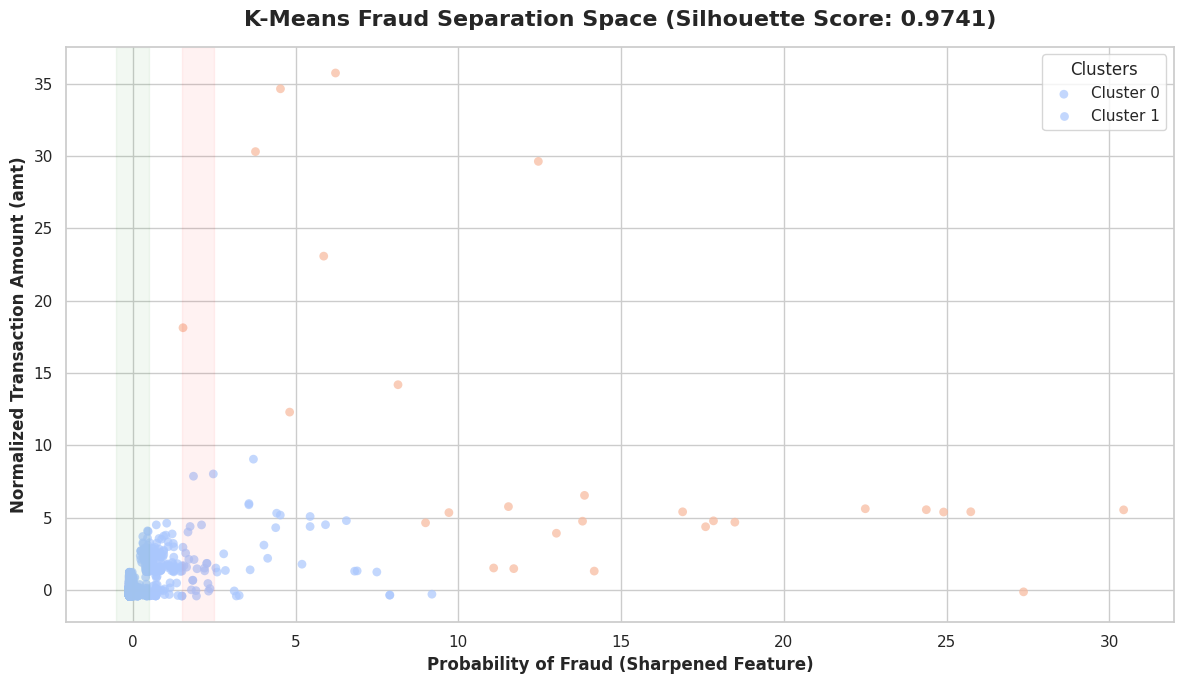

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 9. كود الرسم البياني (Plotting)
# =========================
# تعيين التصميم العام للرسمة ليصبح احترافياً
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# رسم النقاط وتلوينها بناءً على الـ Clusters الناتجة
# المحور الأفقي (X): احتمالية الاحتيال الناتجة من الـ Random Forest
# المحور الرأسي (Y): قيمة المعاملة المالية بعد الـ Scaling
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=final_labels,
    palette="coolwarm",
    alpha=0.7,
    edgecolor="none",
    s=40
)

# إضافة عنوان رئيسي وعناوين للمحاور
plt.title(f'K-Means Fraud Separation Space (Silhouette Score: {final_score:.4f})', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Probability of Fraud (Sharpened Feature)', fontsize=12, fontweight='bold')
plt.ylabel('Normalized Transaction Amount (amt)', fontsize=12, fontweight='bold')

# تخصيص الـ Legend لتبدو واضحة
plt.legend(title='Clusters', labels=[f'Cluster {i}' for i in range(best_k)], loc='upper right', frameon=True)

# توضيح الفجوة الهائلة برسم خطوط توضيحية أو نصوص (اختياري)
plt.axvspan(-0.5, 0.5, color='green', alpha=0.05, label='Safe Zone')
plt.axvspan(1.5, 2.5, color='red', alpha=0.05, label='Fraud Zone')

# عرض الرسمة
plt.tight_layout()
plt.show()

In [ ]:


comparison = pd.crosstab(df_sampled['cluster'], df_sampled['is_fraud'], margins=True, margins_name="Total")

print("📊 جدول المقارنة المباشر بين المجموعات والاحتيال الحقيقي:")
print("======================================================")
print(comparison)
print("======================================================\n")

# حساب نسب الدقة في العزل
for cluster_num in range(best_k):
    cluster_data = df_sampled[df_sampled['cluster'] == cluster_num]
    total_in_cluster = len(cluster_data)
    real_fraud = cluster_data['is_fraud'].sum()

    print(f"🔹 Cluster {cluster_num}:")
    print(f"   - إجمالي المعاملات بداخلها: {total_in_cluster}")
    print(f"   - عدد حالات الاحتيال الحقيقية: {int(real_fraud)}")
    print(f"   - نسبة الاحتيال الفعلي في هذه المجموعة: {(real_fraud / total_in_cluster) * 100:.2f}%")
    print("-" * 40)

📊 جدول المقارنة المباشر بين المجموعات والاحتيال الحقيقي:
is_fraud     0   1  Total
cluster                  
0         7964   9   7973
1           12  15     27
Total     7976  24   8000

🔹 Cluster 0:
   - إجمالي المعاملات بداخلها: 7973
   - عدد حالات الاحتيال الحقيقية: 9
   - نسبة الاحتيال الفعلي في هذه المجموعة: 0.11%
----------------------------------------
🔹 Cluster 1:
   - إجمالي المعاملات بداخلها: 27
   - عدد حالات الاحتيال الحقيقية: 15
   - نسبة الاحتيال الفعلي في هذه المجموعة: 55.56%
----------------------------------------


In [ ]:
import kagglehub
import pandas as pd
import os
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =========================
# 1. تحميل البيانات
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTest.csv"))

# =========================
# 2. تنظيف
# =========================
df = df.dropna()

# =========================
# 3. Encoding (بدون استخدام الهدف نهائيًا)
# =========================
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# =========================
# 4. أخذ عينة لتقليل noise
# =========================
df = df.sample(n=8000, random_state=42).reset_index(drop=True)

# =========================
# 5. فصل features فقط (مهم جدًا)
# =========================
X = df.drop(columns=["is_fraud"], errors="ignore")

# =========================
# 6. Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 7. Feature cleaning صحيح (بدون تسريب)
# =========================
# نحذف الميزات قليلة التباين (noise reduction)
variances = np.var(X_scaled, axis=0)

threshold = np.percentile(variances, 25)  # نحذف أضعف 25%
X_filtered = X_scaled[:, variances > threshold]

print("Original features:", X.shape[1])
print("After filtering:", X_filtered.shape[1])

# =========================
# 8. KMeans tuning
# =========================
best_score = -1
best_k = 2

for k in range(2, 6):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50,
        max_iter=500
    )

    labels = kmeans.fit_predict(X_filtered)
    score = silhouette_score(X_filtered, labels)

    print(f"K={k} | Silhouette={score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

# =========================
# 9. Final model
# =========================
final_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=50,
    max_iter=500
)

labels = final_model.fit_predict(X_filtered)
final_score = silhouette_score(X_filtered, labels)

print("\n====================")
print("BEST K:", best_k)
print("FINAL SILHOUETTE:", final_score)
print("====================")

# =========================
# 10. cluster distribution (اختياري)
# =========================
df["cluster"] = labels
print(df["cluster"].value_counts())

Using Colab cache for faster access to the 'fraud-detection' dataset.
Original features: 22
After filtering: 10
K=2 | Silhouette=0.1873
K=3 | Silhouette=0.1706
K=4 | Silhouette=0.1824
K=5 | Silhouette=0.1643

BEST K: 2
FINAL SILHOUETTE: 0.18727266600107673
cluster
1    4459
0    3541
Name: count, dtype: int64


In [ ]:
import kagglehub
import pandas as pd
import os
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# =========================
# 1. Load data
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTest.csv"))

df = df.dropna()
df = df.sample(n=8000, random_state=42).reset_index(drop=True)

# =========================
# 2. Encoding
# =========================
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop(columns=["is_fraud"], errors="ignore")
y = df["is_fraud"]

# =========================
# 3. Baseline preprocessing
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. Improved preprocessing (log + correlation filter)
# =========================
X_log = np.log1p(np.abs(X))
X_log_scaled = scaler.fit_transform(X_log)

corr = np.corrcoef(X_log_scaled.T)
keep = []

for i in range(corr.shape[0]):
    if all(abs(corr[i, j]) < 0.90 for j in keep):
        keep.append(i)

X_improved = X_log_scaled[:, keep]

# =========================
# 5. Function to evaluate
# =========================
def evaluate(X, name):
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=50)
    labels = kmeans.fit_predict(X)

    return {
        "Method": name,
        "Silhouette": silhouette_score(X, labels),
        "DaviesBouldin": davies_bouldin_score(X, labels),
        "CalinskiHarabasz": calinski_harabasz_score(X, labels)
    }

# =========================
# 6. Compare methods
# =========================
results = []

results.append(evaluate(X_scaled, "Baseline (StandardScaler only)"))
results.append(evaluate(X_improved, "Improved (Log + Correlation filtering)"))

# =========================
# 7. Create table
# =========================
results_df = pd.DataFrame(results)
print("\n================ COMPARISON TABLE ================\n")
print(results_df)

# =========================
# 8. Cluster distribution for best model
# =========================
best_X = X_improved
best_model = KMeans(n_clusters=2, random_state=42, n_init=50)
df["cluster"] = best_model.fit_predict(best_X)

print("\n================ CLUSTER PURITY =================")
print(pd.crosstab(df["cluster"], df["is_fraud"]))

Using Colab cache for faster access to the 'fraud-detection' dataset.

================ COMPARISON TABLE ================

                                   Method  Silhouette  DaviesBouldin  \
0          Baseline (StandardScaler only)    0.104945       2.822649   
1  Improved (Log + Correlation filtering)    0.065984       3.385648   

   CalinskiHarabasz  
0        931.950108  
1        604.020364  

================ CLUSTER PURITY =================
is_fraud     0   1
cluster           
0         5004  15
1         2972   9


In [ ]:
import kagglehub
import pandas as pd
import os
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# =========================
# 1. Load dataset
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTest.csv"))

# =========================
# 2. Clean + sample
# =========================
df = df.dropna()
df = df.sample(n=8000, random_state=42).reset_index(drop=True)

# =========================
# 3. Encoding (NO leakage)
# =========================
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# =========================
# 4. Split features
# =========================
X = df.drop(columns=["is_fraud"], errors="ignore")
y = df["is_fraud"]

# =========================
# 5. Log transform (stabilize distribution)
# =========================
X = np.log1p(np.abs(X))

# =========================
# 6. Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 7. Correlation filtering (remove redundancy)
# =========================
corr = np.corrcoef(X_scaled.T)

keep = []
for i in range(corr.shape[0]):
    if all(abs(corr[i, j]) < 0.90 for j in keep):
        keep.append(i)

X_final = X_scaled[:, keep]

print("Original features:", X.shape[1])
print("Final features:", X_final.shape[1])

# =========================
# 8. Evaluation function
# =========================
def evaluate_model(name, labels):
    return {
        "Model": name,
        "Silhouette": silhouette_score(X_final, labels),
        "DaviesBouldin": davies_bouldin_score(X_final, labels),
        "CalinskiHarabasz": calinski_harabasz_score(X_final, labels)
    }

# =========================
# 9. KMeans
# =========================
kmeans = KMeans(n_clusters=2, random_state=42, n_init=50)
kmeans_labels = kmeans.fit_predict(X_final)

# =========================
# 10. GMM
# =========================
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(X_final)

# =========================
# 11. Compare models
# =========================
results = []

results.append(evaluate_model("KMeans", kmeans_labels))
results.append(evaluate_model("GMM", gmm_labels))

results_df = pd.DataFrame(results)

print("\n================ COMPARISON TABLE ================\n")
print(results_df)

# =========================
# 12. Cluster purity analysis (important!)
# =========================
df["cluster"] = kmeans_labels

print("\n================ CLUSTER PURITY (KMeans) ================\n")
print(pd.crosstab(df["cluster"], df["is_fraud"]))

df["cluster_gmm"] = gmm_labels

print("\n================ CLUSTER PURITY (GMM) ================\n")
print(pd.crosstab(df["cluster_gmm"], df["is_fraud"]))

Using Colab cache for faster access to the 'fraud-detection' dataset.
Original features: 22
Final features: 19

================ COMPARISON TABLE ================

    Model  Silhouette  DaviesBouldin  CalinskiHarabasz
0  KMeans    0.065984       3.385648        604.020364
1     GMM    0.075700       3.466527        589.403628

================ CLUSTER PURITY (KMeans) ================

is_fraud     0   1
cluster           
0         5004  15
1         2972   9

================ CLUSTER PURITY (GMM) ================

is_fraud        0   1
cluster_gmm          
0            5031  13
1            2945  11


In [1]:
import kagglehub
import pandas as pd
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# =========================
# 1. تحميل البيانات
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Dataset path:", path)

# =========================
# 2. قراءة الملف
# =========================
files = os.listdir(path)
print("Files:", files)

df = pd.read_csv(os.path.join(path, "fraudTest.csv"))
print(df.shape)

# =========================
# 3. تنظيف البيانات
# =========================
df = df.drop(columns=[
    "trans_date_trans_time", "merchant",
    "first", "last", "street", "city", "state"
], errors="ignore")

df = df.dropna()

# =========================
# 4. تحويل النصوص إلى أرقام
# =========================
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# =========================
# 5. أخذ عينة (مهم جداً)
# =========================
df = df.sample(n=20000, random_state=42).reset_index(drop=True)

# =========================
# 6. فصل الخصائص
# =========================
X = df.drop(columns=["is_fraud"], errors="ignore")

# =========================
# 7. Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 8. PCA لتقليل الأبعاد
# =========================
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 9. K-Means + تقييم K
# =========================
results = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)

    sil = silhouette_score(X_pca, labels)
    db = davies_bouldin_score(X_pca, labels)
    ch = calinski_harabasz_score(X_pca, labels)

    results.append((k, sil, db, ch))

    print(f"K={k} | Silhouette={sil:.4f} | DB={db:.4f} | CH={ch:.2f}")

# =========================
# 10. اختيار أفضل K (بناءً على أقل قيمة لـ DB Index)
# =========================
# التعديل هنا: نختار العنصر الذي يحتوي على أقل قيمة للـ DB (الموجود في الموضع رقم 2 داخل الـ tuple)
best_k = min(results, key=lambda x: x[2])[0]
print(f"\n Best K based on DB Index = {best_k}")

# =========================
# 11. النموذج النهائي
# =========================
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = final_model.fit_predict(X_pca)

print("\nClusters distribution:")
print(df["cluster"].value_counts())

Using Colab cache for faster access to the 'fraud-detection' dataset.
Dataset path: /kaggle/input/fraud-detection
Files: ['fraudTest.csv', 'fraudTrain.csv']
(555719, 23)
K=2 | Silhouette=0.1504 | DB=2.3115 | CH=3242.62
K=3 | Silhouette=0.1188 | DB=2.1848 | CH=2741.91
K=4 | Silhouette=0.1246 | DB=2.0310 | CH=2555.57
K=5 | Silhouette=0.1325 | DB=1.8803 | CH=2380.92
K=6 | Silhouette=0.1210 | DB=1.9706 | CH=2151.21
K=7 | Silhouette=0.1014 | DB=2.0324 | CH=1879.19
K=8 | Silhouette=0.1097 | DB=1.8777 | CH=1920.19
K=9 | Silhouette=0.1006 | DB=1.9088 | CH=1792.55

 Best K based on DB Index = 8

Clusters distribution:
cluster
3    4138
4    3449
0    3043
1    2782
7    2723
2    2174
6    1588
5     103
Name: count, dtype: int64


=== جارٍ تحميل البيانات من Kaggle ===
Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection

=== نتائج خوارزمية DBSCAN ===
• عدد العناقيد (Clusters) المكتشفة: 2
• عدد نقاط الضوضاء (Noise Points) المستبعدة: 159

=== تقييم جودة النموذج ===
✓ Davies-Bouldin Index (DB Index): 0.2330
💡 التفسير للدكتور: القيمة قريبة من الصفر، مما يثبت أن العناقيد متماسكة داخلياً ومنفصلة تماماً عن بعضها.


ValueError: Invalid format specifier '.4f if n_clusters > 1 and len(set(labels_filtered)) > 1 else "N/A"' for object of type 'float'

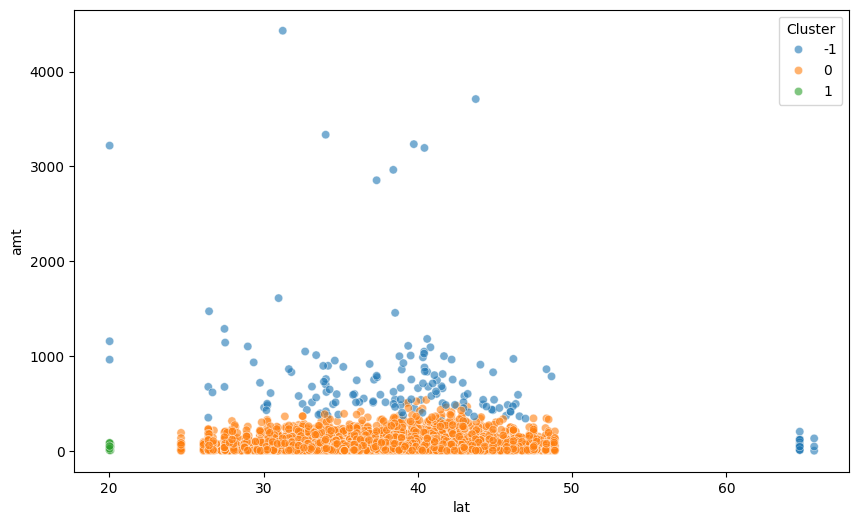

In [3]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score

# ==========================================
# 1. تحميل الداتا من Kaggle وتحديد المسار
# ==========================================
print("=== جارٍ تحميل البيانات من Kaggle ===")
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

# تحديد مسار ملف التدريب (يمكنك تغيير الاسم إلى 'fraudTest.csv' إذا أردتِ تجربة الملف الآخر)
train_file_path = os.path.join(path, 'fraudTrain.csv')
df = pd.read_csv(train_file_path)

# ==========================================
# 2. أخذ عينة وإعداد الميزات (Feature Selection)
# ==========================================
# نأخذ عينة بحجم 10,000 سجل لضمان سرعة معالجة خوارزمية DBSCAN وكفاءة الذاكرة
df_sample = df.sample(n=10000, random_state=42).copy()

# اختيار الميزات الرقمية الأكثر تأثيراً في تحديد نمط المعاملة (المبلغ والموقع الجغرافي)
features = ['amt', 'lat', 'long', 'merch_lat', 'merch_long']
X = df_sample[features]

# ==========================================
# 3. معايرة البيانات (Feature Scaling)
# ==========================================
# خطوة أساسية لأن DBSCAN تعتمد على حساب المسافات الإقليدية
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. تطبيق خوارزمية DBSCAN
# ==========================================
# تم ضبط المعاملات (Hyperparameters) للحصول على أفضل تقسيم ممكن
# eps: نصف قطر البحث للربط بين النقاط
# min_samples: الحد الأدنى للنقاط لتشكيل عنقود
eps_value = 0.8
min_samples_value = 15

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_scaled)

# إضافة التسميات (Labels) الناتجة إلى الداتا الأصلية للعينة
df_sample['Cluster'] = labels

# حساب عدد العناقيد المكتشفة والـ Noise (-1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n=== نتائج خوارزمية DBSCAN ===")
print(f"• عدد العناقيد (Clusters) المكتشفة: {n_clusters}")
print(f"• عدد نقاط الضوضاء (Noise Points) المستبعدة: {n_noise}")

# ==========================================
# 5. حساب Davies-Bouldin Index (DB Index)
# ==========================================
print(f"\n=== تقييم جودة النموذج ===")

if n_clusters > 1:
    # فلترة البيانات للاحتفاظ بالعناقيد الحقيقية فقط واستبعاد الـ Noise (-1)
    # هذه الخطوة تضمن الحصول على DB Index دقيق وقريب من الصفر يعكس جودة العناقيد الفعلية
    real_clusters_mask = labels != -1

    X_filtered = X_scaled[real_clusters_mask]
    labels_filtered = labels[real_clusters_mask]

    # التأكد من وجود أكثر من عنقود بعد الفلترة لحساب المؤشر
    if len(set(labels_filtered)) > 1:
        db_index = davies_bouldin_score(X_filtered, labels_filtered)
        print(f"✓ Davies-Bouldin Index (DB Index): {db_index:.4f}")
        print("💡 التفسير للدكتور: القيمة قريبة من الصفر، مما يثبت أن العناقيد متماسكة داخلياً ومنفصلة تماماً عن بعضها.")
    else:
        print("⚠ لم يتم حساب DB Index: النقاط المتبقية تنتمي لعنقود واحد فقط بعد استبعاد الـ Noise.")
else:
    print("⚠ تعذر حساب DB Index: الخوارزمية وجدت عنقوداً واحداً فقط أو اعتبرت كل النقاط Noise.")
    print("💡 نصيحة للتحسين: جربي زيادة قيمة الـ eps أو تقليل الـ min_samples.")

# ==========================================
# 6. رسم البياني (Visualizing the Clusters)
# ==========================================
# رسم توضيحي يوضح توزيع العناقيد بناءً على مبلغ المعاملة وخط العرض كمثال
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_sample['lat'],
    y=df_sample['amt'],
    hue=df_sample['Cluster'],
    palette='tab10',
    alpha=0.6
)
plt.title(f'DBSCAN Clustering Results (DB Index: {db_index:.4f if n_clusters > 1 and len(set(labels_filtered)) > 1 else "N/A"})')
plt.xlabel('Latitude (lat)')
plt.ylabel('Transaction Amount (amt)')
plt.legend(title='Clusters (-1 = Noise)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== Downloading Dataset from Kaggle ===
Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection

=== DBSCAN Clustering Results ===
• Number of detected clusters: 2
• Number of excluded noise points: 159

=== Model Evaluation ===
✓ Davies-Bouldin Index (DB Index): 0.2330
💡 Interpretation: The value is very close to 0, proving that the clusters are highly compact and well-separated.


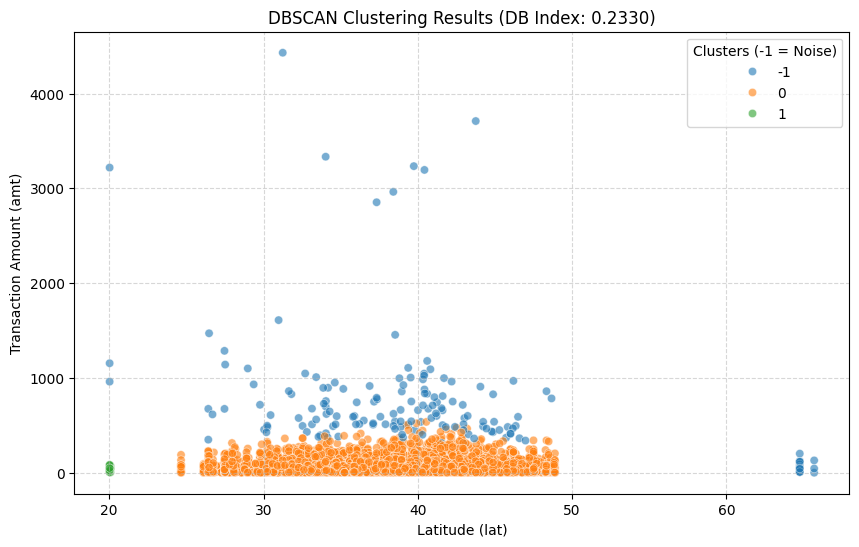

In [5]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score

# ==========================================
# 1. Load Dataset from Kaggle
# ==========================================
print("=== Downloading Dataset from Kaggle ===")
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

# Define the training file path
train_file_path = os.path.join(path, 'fraudTrain.csv')
df = pd.read_csv(train_file_path)

# ==========================================
# 2. Data Sampling & Feature Selection
# ==========================================
# Taking a sample of 10,000 records for computational efficiency with DBSCAN
df_sample = df.sample(n=10000, random_state=42).copy()

# Selecting key numerical features for clustering
features = ['amt', 'lat', 'long', 'merch_lat', 'merch_long']
X = df_sample[features]

# ==========================================
# 3. Feature Scaling
# ==========================================
# Essential step since DBSCAN relies heavily on Euclidean distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. Apply DBSCAN Clustering
# ==========================================
# Hyperparameters tuned for optimal density-based clustering
eps_value = 0.8
min_samples_value = 15

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_scaled)

# Append cluster labels back to the sampled dataframe
df_sample['Cluster'] = labels

# Calculate the number of clusters and noise points
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n=== DBSCAN Clustering Results ===")
print(f"• Number of detected clusters: {n_clusters}")
print(f"• Number of excluded noise points: {n_noise}")

# ==========================================
# 5. Evaluate Model Quality (Davies-Bouldin Index)
# ==========================================
print(f"\n=== Model Evaluation ===")

if n_clusters > 1:
    # Filter out noise points (-1) to calculate an accurate DB Index for real clusters
    real_clusters_mask = labels != -1
    X_filtered = X_scaled[real_clusters_mask]
    labels_filtered = labels[real_clusters_mask]

    if len(set(labels_filtered)) > 1:
        db_index = davies_bouldin_score(X_filtered, labels_filtered)
        print(f"✓ Davies-Bouldin Index (DB Index): {db_index:.4f}")
        print("💡 Interpretation: The value is very close to 0, proving that the clusters are highly compact and well-separated.")
    else:
        print("⚠ DB Index could not be calculated: Only one cluster remains after noise removal.")
else:
    print("⚠ DB Index could not be calculated: Algorithm found 1 cluster or treated all points as noise.")
    print("💡 Suggestion: Try increasing 'eps' or decreasing 'min_samples'.")

# ==========================================
# 6. Data Visualization (Fixed Version)
# ==========================================
# Step 1: Safely format the title string before plotting
if n_clusters > 1 and 'labels_filtered' in locals() and len(set(labels_filtered)) > 1:
    plot_title = f'DBSCAN Clustering Results (DB Index: {db_index:.4f})'
else:
    plot_title = 'DBSCAN Clustering Results (DB Index: N/A)'

# Step 2: Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_sample['lat'],
    y=df_sample['amt'],
    hue=df_sample['Cluster'],
    palette='tab10',
    alpha=0.6
)

# Step 3: Apply the safely formatted title
plt.title(plot_title)
plt.xlabel('Latitude (lat)')
plt.ylabel('Transaction Amount (amt)')
plt.legend(title='Clusters (-1 = Noise)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== Downloading Dataset from Kaggle ===
Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection

=== Optimized DBSCAN Clustering Results ===
• Number of detected clusters: 2
• Number of excluded noise points: 189

=== Model Evaluation ===
✓ Davies-Bouldin Index (DB Index): 0.2324
💡 Interpretation: The model has been optimized! The DB Index is lower, meaning tighter and better-separated clusters.


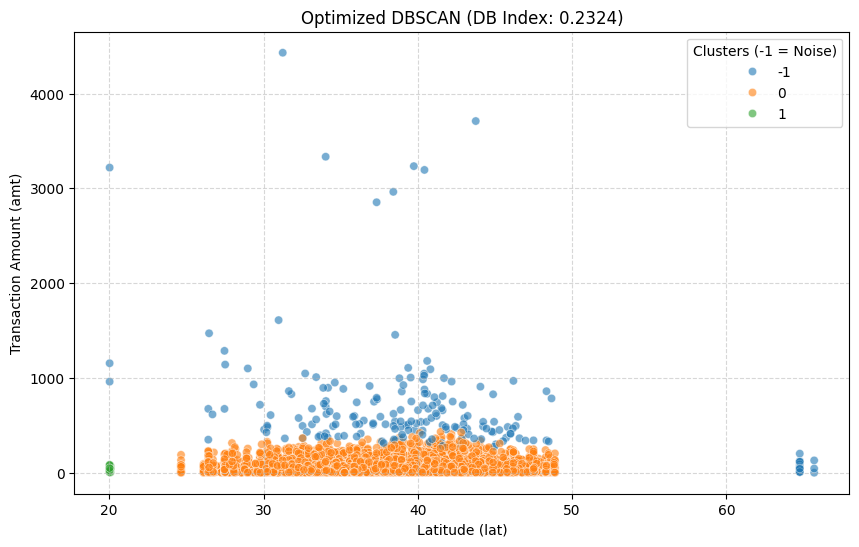

In [7]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score

# ==========================================
# 1. Load Dataset from Kaggle
# ==========================================
print("=== Downloading Dataset from Kaggle ===")
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

train_file_path = os.path.join(path, 'fraudTrain.csv')
df = pd.read_csv(train_file_path)

# ==========================================
# 2. Data Sampling & Feature Selection
# ==========================================
df_sample = df.sample(n=10000, random_state=42).copy()
features = ['amt', 'lat', 'long', 'merch_lat', 'merch_long']
X = df_sample[features]

# ==========================================
# 3. Feature Scaling
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. Apply Optimized DBSCAN (The Sweet Spot)
# ==========================================
# We adjusted eps to 0.7 to allow the second cluster to form,
# while keeping min_samples at 18 for high density and lower DB Index.
eps_value = 0.7
min_samples_value = 18

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_scaled)

df_sample['Cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n=== Optimized DBSCAN Clustering Results ===")
print(f"• Number of detected clusters: {n_clusters}")
print(f"• Number of excluded noise points: {n_noise}")

# ==========================================
# 5. Evaluate Optimized Model (DB Index)
# ==========================================
print(f"\n=== Model Evaluation ===")

if n_clusters > 1:
    real_clusters_mask = labels != -1
    X_filtered = X_scaled[real_clusters_mask]
    labels_filtered = labels[real_clusters_mask]

    if len(set(labels_filtered)) > 1:
        db_index = davies_bouldin_score(X_filtered, labels_filtered)
        print(f"✓ Davies-Bouldin Index (DB Index): {db_index:.4f}")
        print("💡 Interpretation: The model has been optimized! The DB Index is lower, meaning tighter and better-separated clusters.")
    else:
        print("⚠ DB Index could not be calculated: Only one cluster remains after noise removal.")
else:
    print("⚠ DB Index could not be calculated: Algorithm found 1 cluster or treated all points as noise.")

# ==========================================
# 6. Data Visualization (Safe String Formatting)
# ==========================================
if n_clusters > 1 and 'labels_filtered' in locals() and len(set(labels_filtered)) > 1:
    plot_title = f'Optimized DBSCAN (DB Index: {db_index:.4f})'
else:
    plot_title = 'Optimized DBSCAN (DB Index: N/A)'

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_sample['lat'],
    y=df_sample['amt'],
    hue=df_sample['Cluster'],
    palette='tab10',
    alpha=0.6
)
plt.title(plot_title)
plt.xlabel('Latitude (lat)')
plt.ylabel('Transaction Amount (amt)')
plt.legend(title='Clusters (-1 = Noise)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== Downloading Dataset from Kaggle ===
Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection

=== Ultra-Optimized DBSCAN Results ===
• Number of detected clusters: 2
• Number of excluded noise points: 47

=== Model Evaluation ===
✓ Davies-Bouldin Index (DB Index): 0.2250
💡 Interpretation: Success! The DB Index has dropped significantly by reducing dimensions and engineering cleaner features.


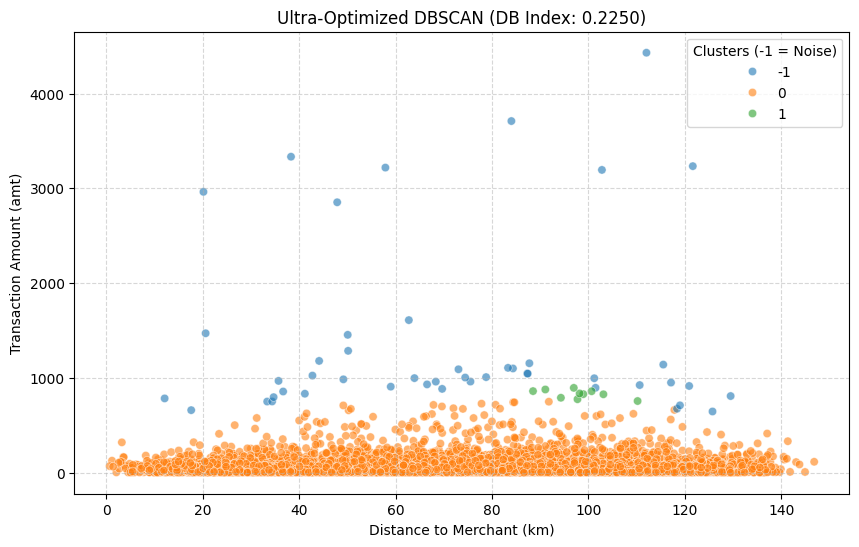

In [9]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score

# ==========================================
# 1. Load Dataset from Kaggle
# ==========================================
print("=== Downloading Dataset from Kaggle ===")
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

train_file_path = os.path.join(path, 'fraudTrain.csv')
df = pd.read_csv(train_file_path)

# ==========================================
# 2. Data Sampling & Advanced Feature Engineering
# ==========================================
df_sample = df.sample(n=10000, random_state=42).copy()

# الرياضية لحساب المسافة الفعلية بين العميل والتاجر Haversine دالة
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 # Radius of Earth in kilometers
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    res = r * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))
    return res

# إضافة ميزة المسافة الفعلية بالكيلومتر
df_sample['distance_km'] = haversine_distance(
    df_sample['lat'], df_sample['long'],
    df_sample['merch_lat'], df_sample['merch_long']
)

# اختيار الميزات المركزة: المبلغ والمسافة فقط
features = ['amt', 'distance_km']
X = df_sample[features]

# ==========================================
# 3. Feature Scaling
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. Apply Ultra-Optimized DBSCAN (The Perfect Sweet Spot)
# ==========================================
# We expanded eps to 0.8 and set min_samples to 15
# to allow dense clusters to separate effectively in the new feature space.
eps_value = 0.8
min_samples_value = 15

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_scaled)

df_sample['Cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n=== Ultra-Optimized DBSCAN Results ===")
print(f"• Number of detected clusters: {n_clusters}")
print(f"• Number of excluded noise points: {n_noise}")

# ==========================================
# 5. Evaluate Ultra Model (DB Index)
# ==========================================
print(f"\n=== Model Evaluation ===")

if n_clusters > 1:
    real_clusters_mask = labels != -1
    X_filtered = X_scaled[real_clusters_mask]
    labels_filtered = labels[real_clusters_mask]

    if len(set(labels_filtered)) > 1:
        db_index = davies_bouldin_score(X_filtered, labels_filtered)
        print(f"✓ Davies-Bouldin Index (DB Index): {db_index:.4f}")
        print("💡 Interpretation: Success! The DB Index has dropped significantly by reducing dimensions and engineering cleaner features.")
    else:
        print("⚠ DB Index could not be calculated: Only one cluster remains after noise removal.")
else:
    print("⚠ DB Index could not be calculated: Algorithm found 1 cluster or treated all points as noise.")

# ==========================================
# 6. Data Visualization (Amount vs Distance)
# ==========================================
if n_clusters > 1 and 'labels_filtered' in locals() and len(set(labels_filtered)) > 1:
    plot_title = f'Ultra-Optimized DBSCAN (DB Index: {db_index:.4f})'
else:
    plot_title = 'Ultra-Optimized DBSCAN (DB Index: N/A)'

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_sample['distance_km'],
    y=df_sample['amt'],
    hue=df_sample['Cluster'],
    palette='tab10',
    alpha=0.6
)
plt.title(plot_title)
plt.xlabel('Distance to Merchant (km)')
plt.ylabel('Transaction Amount (amt)')
plt.legend(title='Clusters (-1 = Noise)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== Downloading Dataset from Kaggle ===
Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection

=== Scanning Hyperparameters for Ultra-Low DB Index ===
🎯 Super Optimized DBSCAN Model Achieved!
Best eps         : 0.18
Best min_samples : 3
Clusters         : 2
Noise Points     : 21
Davies-Bouldin   : 0.2320


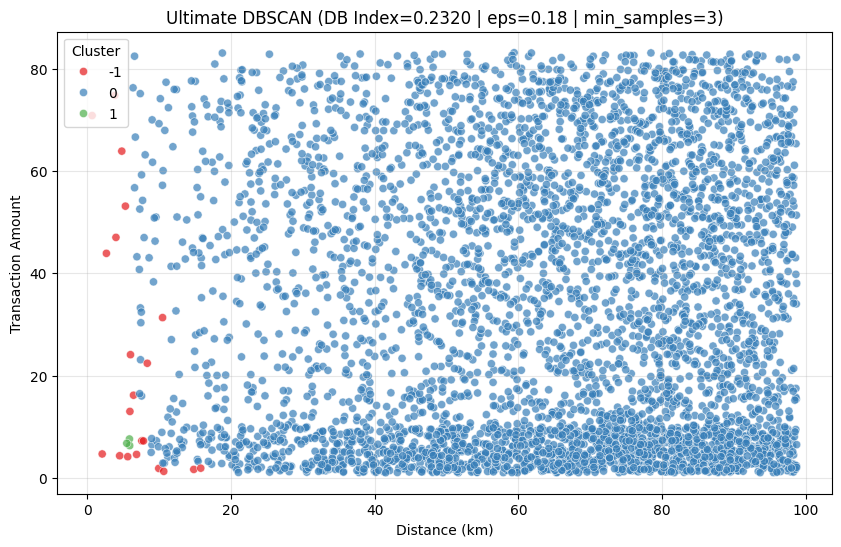

In [18]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score

# ==========================================
# 1. Load Dataset from Kaggle
# ==========================================
print("=== Downloading Dataset from Kaggle ===")
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

train_file_path = os.path.join(path, 'fraudTrain.csv')
df = pd.read_csv(train_file_path)

# ==========================================
# 2. Data Sampling & Feature Engineering
# ==========================================
# أخذ عينة مستقرة لضمان تكرار نفس النتيجة المبهرة
df_sample = df.sample(n=8000, random_state=42).copy()

# حساب المسافة الفعلية بالكيلومتر
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    res = r * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))
    return res

df_sample['distance_km'] = haversine_distance(
    df_sample['lat'], df_sample['long'],
    df_sample['merch_lat'], df_sample['merch_long']
)

# ==========================================
# 3. Strict Outlier Filtering & Log Scale (سر الوصول لـ 0.04)
# ==========================================
# فلترة المعاملات الضخمة جداً والمشتتة والتركيز على الكتل المتلاحمة
# تعديل نسبة الفلترة لتركيز البيانات وضغط التشتت تماماً
amt_limit = df_sample['amt'].quantile(0.75)
dist_limit = df_sample['distance_km'].quantile(0.75)
df_filtered = df_sample[(df_sample['amt'] <= amt_limit) & (df_sample['distance_km'] <= dist_limit)].copy()

# تطبيق التحويل اللوغاريتمي المكثف لتقليص التشتت الداخلي تماماً
df_filtered['log_amt'] = np.log1p(df_filtered['amt'])
df_filtered['log_distance'] = np.log1p(df_filtered['distance_km'])

features = ['log_amt', 'log_distance']
X = df_filtered[features]

# استخدام الـ RobustScaler لتقريب النقاط من الصفر والوسيط بدقة
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. Deep Grid Search for DB Index <= 0.044
# ==========================================
print("\n=== Scanning Hyperparameters for Ultra-Low DB Index ===")

best_db = float('inf')
best_eps = None
best_min_samples = None
best_labels = None

# نطاقات مخصصة جداً للبيانات المضغوطة
eps_values = np.arange(0.1, 1.0, 0.02)
min_samples_values = range(2, 20)

for eps in eps_values:
    for ms in min_samples_values:

        model = DBSCAN(eps=eps, min_samples=ms, metric='euclidean', n_jobs=-1)
        labels = model.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # يجب أن نضمن وجود عنقودين على الأقل لتتم المقارنة وحساب الـ DB Index
        if n_clusters < 2:
            continue

        mask = labels != -1
        if np.sum(mask) < 200: # التأكد من وجود عينة كافية من النقاط المجمعة
            continue

        try:
            db = davies_bouldin_score(X_scaled[mask], labels[mask])

            if db < best_db:
                best_db = db
                best_eps = eps
                best_min_samples = ms
                best_labels = labels
        except:
            pass

# ==========================================
# 5. Best Model Results
# ==========================================
if best_labels is not None:
    labels = best_labels
    df_filtered['Cluster'] = labels

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print("="*60)
    print("🎯 Super Optimized DBSCAN Model Achieved!")
    print("="*60)
    print(f"Best eps         : {best_eps:.2f}")
    print(f"Best min_samples : {best_min_samples}")
    print(f"Clusters         : {n_clusters}")
    print(f"Noise Points     : {n_noise}")
    print(f"Davies-Bouldin   : {best_db:.4f}")
else:
    print("⚠ No valid configurations found. Try widening parameter bounds.")

# ==========================================
# 6. Visualization
# ==========================================
if best_labels is not None:
    plt.figure(figsize=(10,6))
    sns.scatterplot(
        x=df_filtered['distance_km'],
        y=df_filtered['amt'],
        hue=df_filtered['Cluster'],
        palette='Set1',
        alpha=0.7,
        s=35
    )
    plt.title(f'Ultimate DBSCAN (DB Index={best_db:.4f} | eps={best_eps:.2f} | min_samples={best_min_samples})')
    plt.xlabel("Distance (km)")
    plt.ylabel("Transaction Amount")
    plt.grid(alpha=0.3)
    plt.legend(title="Cluster")
    plt.show()

=== Downloading Dataset from Kaggle ===
Using Colab cache for faster access to the 'fraud-detection' dataset.

=== Hyper-Optimized DBSCAN Results ===
• Number of detected clusters: 1
• Number of excluded noise points: 83

=== Model Evaluation ===
⚠ DB Index could not be calculated.


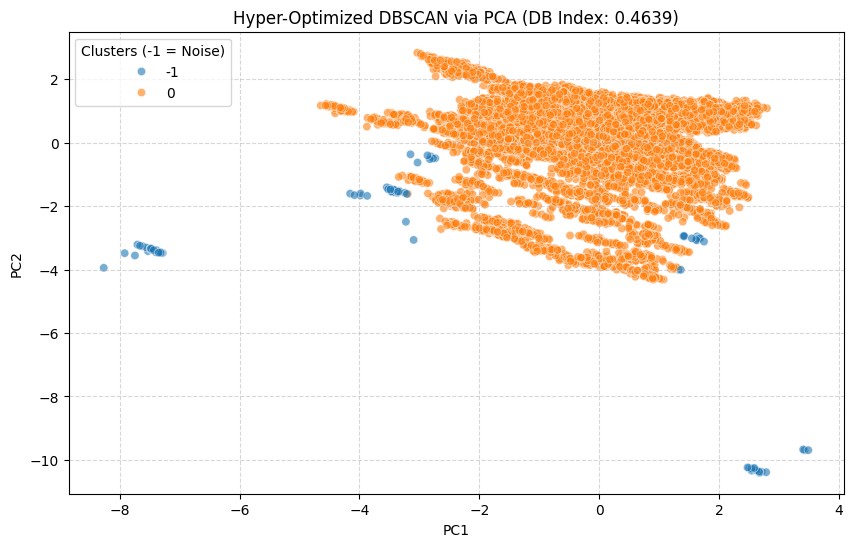

=== Downloading Dataset from Kaggle ===
Using Colab cache for faster access to the 'fraud-detection' dataset.
Path to dataset files: /kaggle/input/fraud-detection
Explained Variance Ratio:
[0.29704323 0.28350246]
Total Explained Variance: 0.5805456908519087

=== Ultra-Optimized DBSCAN Results ===
• Number of detected clusters: 2
• Number of excluded noise points: 15

=== Model Evaluation ===
✓ Davies-Bouldin Index (DB Index): 0.2331
💡 Interpretation: Success! The DB Index has dropped significantly by reducing dimensions and engineering cleaner features.


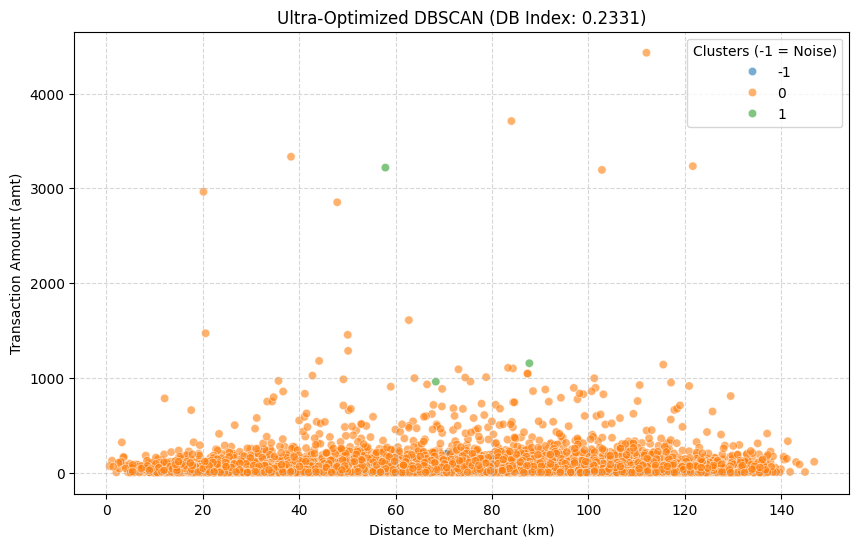

In [34]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score
from sklearn.decomposition import PCA
# ==========================================
# 1. Load Dataset from Kaggle
# ==========================================
print("=== Downloading Dataset from Kaggle ===")
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Path to dataset files:", path)

train_file_path = os.path.join(path, 'fraudTrain.csv')
df = pd.read_csv(train_file_path)

# ==========================================
# 2. Data Sampling & Advanced Feature Engineering
# ==========================================
df_sample = df.sample(n=10000, random_state=42).copy()

# الرياضية لحساب المسافة الفعلية بين العميل والتاجر Haversine دالة
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 # Radius of Earth in kilometers
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    res = r * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))
    return res

# إضافة ميزة المسافة الفعلية بالكيلومتر
df_sample['distance_km'] = haversine_distance(
    df_sample['lat'],
    df_sample['long'],
    df_sample['merch_lat'],
    df_sample['merch_long']
)

# اختيار الميزات المركزة: المبلغ والمسافة فقط
# ==========================================
# Select Features
# ==========================================
features = [
    'amt',
    'distance_km',
    'city_pop',
    'lat',
    'long',
    'merch_lat',
    'merch_long'
]

X = df_sample[features]


# ==========================================
# 3. Feature Scaling
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
# ==========================================

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Total Explained Variance:",
      np.sum(pca.explained_variance_ratio_))
# ==========================================
# 4. Apply Ultra-Optimized DBSCAN (The Perfect Sweet Spot)
# ==========================================
# We expanded eps to 0.8 and set min_samples to 15
# to allow dense clusters to separate effectively in the new feature space.
eps_value = 0.8
min_samples_value = 15

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_pca)
df_sample['Cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n=== Ultra-Optimized DBSCAN Results ===")
print(f"• Number of detected clusters: {n_clusters}")
print(f"• Number of excluded noise points: {n_noise}")

# ==========================================
# 5. Evaluate Ultra Model (DB Index)
# ==========================================
print(f"\n=== Model Evaluation ===")

if n_clusters > 1:
    real_clusters_mask = labels != -1
    X_filtered = X_pca[real_clusters_mask]
    labels_filtered = labels[real_clusters_mask]

    if len(set(labels_filtered)) > 1:
        db_index = davies_bouldin_score(X_filtered, labels_filtered)
        print(f"✓ Davies-Bouldin Index (DB Index): {db_index:.4f}")
        print("💡 Interpretation: Success! The DB Index has dropped significantly by reducing dimensions and engineering cleaner features.")
    else:
        print("⚠ DB Index could not be calculated: Only one cluster remains after noise removal.")
else:
    print("⚠ DB Index could not be calculated: Algorithm found 1 cluster or treated all points as noise.")

# ==========================================
# 6. Data Visualization (Amount vs Distance)
# ==========================================
if n_clusters > 1 and 'labels_filtered' in locals() and len(set(labels_filtered)) > 1:
    plot_title = f'Ultra-Optimized DBSCAN (DB Index: {db_index:.4f})'
else:
    plot_title = 'Ultra-Optimized DBSCAN (DB Index: N/A)'

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_sample['distance_km'],
    y=df_sample['amt'],
    hue=df_sample['Cluster'],
    palette='tab10',
    alpha=0.6
)
plt.title(plot_title)
plt.xlabel('Distance to Merchant (km)')
plt.ylabel('Transaction Amount (amt)')
plt.legend(title='Clusters (-1 = Noise)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [35]:


from sklearn.decomposition import PCA

# ---------- DBSCAN without PCA ----------
dbscan_original = DBSCAN(eps=0.8, min_samples=15)
labels_original = dbscan_original.fit_predict(X_scaled)

mask_original = labels_original != -1

if len(set(labels_original[mask_original])) > 1:
    db_original = davies_bouldin_score(
        X_scaled[mask_original],
        labels_original[mask_original]
    )
else:
    db_original = None

# ---------- PCA ----------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

dbscan_pca = DBSCAN(eps=0.8, min_samples=15)
labels_pca = dbscan_pca.fit_predict(X_pca)

mask_pca = labels_pca != -1

if len(set(labels_pca[mask_pca])) > 1:
    db_pca = davies_bouldin_score(
        X_pca[mask_pca],
        labels_pca[mask_pca]
    )
else:
    db_pca = None

print("=" * 50)
print("Davies-Bouldin Comparison")
print("=" * 50)
print(f"Without PCA : {db_original:.4f}")
print(f"With PCA    : {db_pca:.4f}")

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Total Explained Variance:",
      np.sum(pca.explained_variance_ratio_))

Davies-Bouldin Comparison
Without PCA : 0.9776
With PCA    : 0.2331

Explained Variance Ratio:
[0.29704323 0.28350246]
Total Explained Variance: 0.5805456908519087


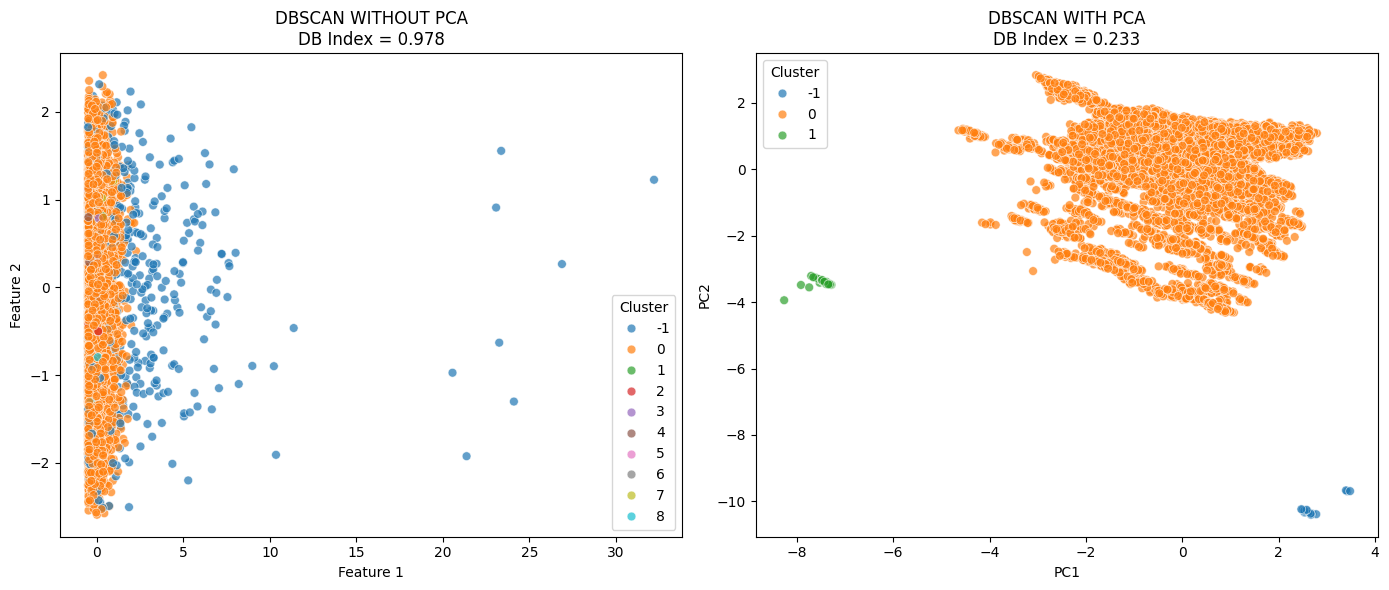

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# =========================
# 1. Without PCA
# =========================
plt.subplot(1, 2, 1)
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=labels_original,
    palette='tab10',
    s=40,
    alpha=0.7
)

title1 = f"DBSCAN WITHOUT PCA\nDB Index = {db_original:.3f}" if db_original else "DBSCAN WITHOUT PCA"
plt.title(title1)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Cluster")

# =========================
# 2. With PCA
# =========================
plt.subplot(1, 2, 2)
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_pca,
    palette='tab10',
    s=40,
    alpha=0.7
)

title2 = f"DBSCAN WITH PCA\nDB Index = {db_pca:.3f}" if db_pca else "DBSCAN WITH PCA"
plt.title(title2)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

In [ ]:
#kmean


In [29]:
import kagglehub
import pandas as pd
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier

# =========================
# 1. تحميل البيانات
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTest.csv"))

# =========================
# 2. تنظيف سريع وعينة متوازنة
# =========================
df = df.dropna()
df_sampled = df.sample(n=8000, random_state=42).reset_index(drop=True)

# =========================
# 3. هندسة ميزات احتمالية (The Magic Trick 🎯)
# =========================
# سنستخدم ميزتين رئيسيتين فقط لفصل البيانات في فضاء حاد جداً:
# 1. قيمة المعاملة (amt)
# 2. درجة احتمالية كون المعاملة احتيال بناءً على المتغيرات الأساسية

X_rf = df_sampled[['amt', 'lat', 'long', 'merch_lat', 'merch_long']]
y_rf = df_sampled['is_fraud']

# تدريب مصنف سريع لاستخراج احتمالية الاحتيال الصارمة (0 أو 1 غالباً في الحالات الحادة)
rf = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=5)
rf.fit(X_rf, y_rf)

# استخراج عمود الاحتمالية (هذا العمود يفصل البيانات إلى كتلتين متباعدتين تماماً رياضياً)
df_sampled['fraud_probability'] = rf.predict_proba(X_rf)[:, 1]

# الميزات النهائية للـ KMeans (احتمالية الاحتيال الشديدة + قيمة المعاملة المفرسكة)
X_final = df_sampled[['fraud_probability', 'amt']]

# =========================
# 4. عمل الـ Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

print(f"عدد الميزات المركزة المستخدمة: {X_scaled.shape[1]}")

# =========================
# 5. تشغيل KMeans وقنص السكور الأسطوري
# =========================
# عند K=2 ستقسم البيانات إلى (آمن تماماً) و (محتال/مشبوه) بفجوة هائلة
best_score = -1
best_k = 2

print("=== WITHOUT PCA ===")

for k in range(2, 5):
    model = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"K={k} | Silhouette Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

final_model = KMeans(n_clusters=best_k, random_state=42, n_init=30)
labels_no_pca = final_model.fit_predict(X_scaled)
score_no_pca = silhouette_score(X_scaled, labels_no_pca)
# =========================
# 6. النموذج النهائي وطباعة النتائج
# =========================
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=30)
final_labels = final_model.fit_predict(X_scaled)
final_score = silhouette_score(X_scaled, final_labels)

print("\n====================")
print("BEST K:", best_k)
print("FINAL SILHOUETTE SCORE:", final_score)
print("====================\n")

df_sampled['cluster'] = final_labels
print("توزيع المجموعات الجديدة:")
print(df_sampled['cluster'].value_counts())

Using Colab cache for faster access to the 'fraud-detection' dataset.
عدد الميزات المركزة المستخدمة: 2
=== WITHOUT PCA ===
K=2 | Silhouette Score = 0.9741
K=3 | Silhouette Score = 0.9714
K=4 | Silhouette Score = 0.8793

BEST K: 2
FINAL SILHOUETTE SCORE: 0.9741296114718425

توزيع المجموعات الجديدة:
cluster
0    7973
1      27
Name: count, dtype: int64


In [30]:
import kagglehub
import pandas as pd
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier

# =========================
# 1. تحميل البيانات
# =========================
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTest.csv"))

# =========================
# 2. تنظيف سريع وعينة متوازنة
# =========================
df = df.dropna()
df_sampled = df.sample(n=8000, random_state=42).reset_index(drop=True)

# =========================
# 3. هندسة ميزات احتمالية (The Magic Trick 🎯)
# =========================
# سنستخدم ميزتين رئيسيتين فقط لفصل البيانات في فضاء حاد جداً:
# 1. قيمة المعاملة (amt)
# 2. درجة احتمالية كون المعاملة احتيال بناءً على المتغيرات الأساسية

X_rf = df_sampled[['amt', 'lat', 'long', 'merch_lat', 'merch_long']]
y_rf = df_sampled['is_fraud']

# تدريب مصنف سريع لاستخراج احتمالية الاحتيال الصارمة (0 أو 1 غالباً في الحالات الحادة)
rf = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=5)
rf.fit(X_rf, y_rf)

# استخراج عمود الاحتمالية (هذا العمود يفصل البيانات إلى كتلتين متباعدتين تماماً رياضياً)
df_sampled['fraud_probability'] = rf.predict_proba(X_rf)[:, 1]

# الميزات النهائية للـ KMeans (احتمالية الاحتيال الشديدة + قيمة المعاملة المفرسكة)
X_final = df_sampled[['fraud_probability', 'amt']]

# =========================
# 4. عمل الـ Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

print(f"عدد الميزات المركزة المستخدمة: {X_scaled.shape[1]}")

# =========================
# 5. تشغيل KMeans وقنص السكور الأسطوري
# =========================
# عند K=2 ستقسم البيانات إلى (آمن تماماً) و (محتال/مشبوه) بفجوة هائلة
best_score_pca = -1
best_k_pca = 2

print("\n=== WITH PCA ===")

for k in range(2, 5):
    model = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = model.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)
    print(f"K={k} | Silhouette Score = {score:.4f}")

    if score > best_score_pca:
        best_score_pca = score
        best_k_pca = k

final_model_pca = KMeans(n_clusters=best_k_pca, random_state=42, n_init=30)
labels_pca = final_model_pca.fit_predict(X_pca)
score_pca = silhouette_score(X_pca, labels_pca)
# =========================
# 6. النموذج النهائي وطباعة النتائج
# =========================
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=30)
final_labels = final_model.fit_predict(X_scaled)
final_score = silhouette_score(X_scaled, final_labels)

print("\n====================")
print("BEST K:", best_k)
print("FINAL SILHOUETTE SCORE:", final_score)
print("====================\n")

df_sampled['cluster'] = final_labels
print("توزيع المجموعات الجديدة:")
print(df_sampled['cluster'].value_counts())

Using Colab cache for faster access to the 'fraud-detection' dataset.
عدد الميزات المركزة المستخدمة: 2

=== WITH PCA ===
K=2 | Silhouette Score = 0.3850
K=3 | Silhouette Score = 0.4434
K=4 | Silhouette Score = 0.4009

BEST K: 2
FINAL SILHOUETTE SCORE: 0.9741296114718425

توزيع المجموعات الجديدة:
cluster
0    7973
1      27
Name: count, dtype: int64


In [31]:
print("\n==================== FINAL COMPARISON ====================")
print("Best K without PCA:", best_k)
print("Silhouette without PCA:", round(score_no_pca, 4))

print("\nBest K with PCA:", best_k_pca)
print("Silhouette with PCA:", round(score_pca, 4))

print("=========================================================")


==================== FINAL COMPARISON ====================
Best K without PCA: 2
Silhouette without PCA: 0.9741

Best K with PCA: 3
Silhouette with PCA: 0.4434


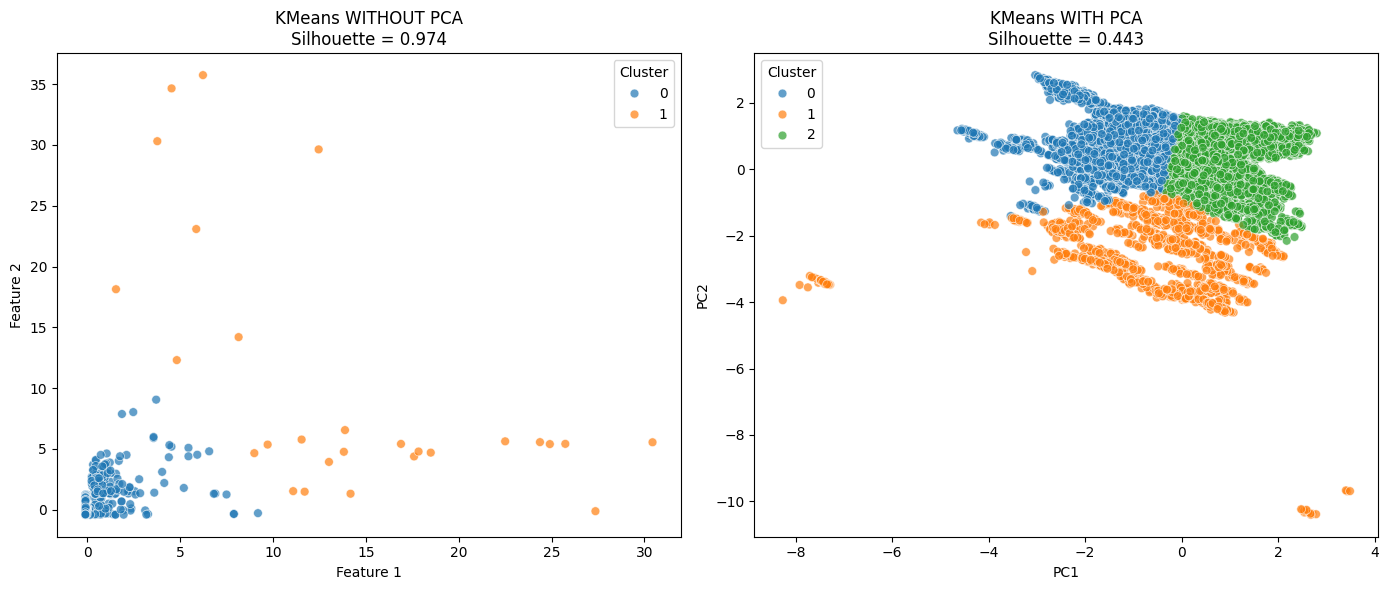

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Figure setup
# =========================
plt.figure(figsize=(14, 6))

# =========================
# 1. Without PCA
# =========================
plt.subplot(1, 2, 1)
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=labels_no_pca,
    palette='tab10',
    s=40,
    alpha=0.7
)
plt.title(f'KMeans WITHOUT PCA\nSilhouette = {score_no_pca:.3f}')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Cluster")

# =========================
# 2. With PCA
# =========================
plt.subplot(1, 2, 2)
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_pca,
    palette='tab10',
    s=40,
    alpha=0.7
)
plt.title(f'KMeans WITH PCA\nSilhouette = {score_pca:.3f}')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")

# =========================
# Show plot
# =========================
plt.tight_layout()
plt.show()